# 04 - Segmentation (Notebook)

Notebook ini meniru alur EDA / Preprocessing: menjelaskan tujuan, menyiapkan environment, menjalankan metode segmentasi klasik, serta mengimplementasikan ensemble sederhana: HSV (atau KMeans) untuk inisialisasi → GrabCut refine → morphology close/open → threshold area filter.

In [ ]:
import sys
from pathlib import Path
project_root = Path('..').resolve()
sys.path.append(str(project_root / 'src'))
import cv2, numpy as np, matplotlib.pyplot as plt
from segmentation import (
    hsv_segmentation,
    kmeans_segmentation,
    ensemble_pipeline,
    batch_ensemble_save,
    batch_ensemble_all,
    evaluate_directory,
    iou,
    dice,
)

plt.rcParams['figure.figsize'] = (10,6)

)

plt.rcParams['figure.figsize'] = (10,6)

In [ ]:
# Core pipeline is implemented in src/segmentation.py.
# This notebook imports reusable functions so the logic stays synchronized
# with the script version and is easier to maintain.

print('Imported ensemble pipeline from src/segmentation.py')

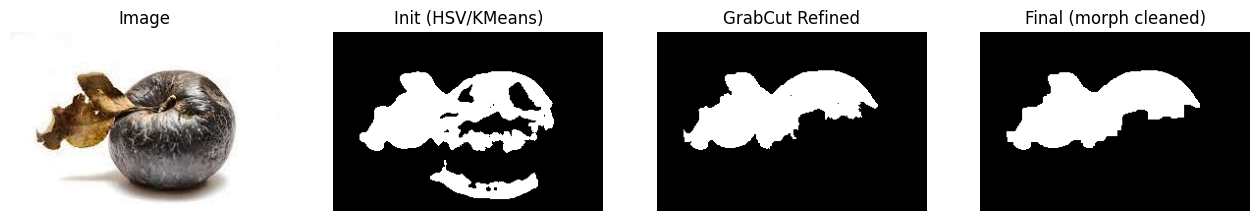

In [6]:
# Example: run on one sample image and visualize
from pathlib import Path
sample = (Path('..') / 'data' / 'enhanced' / 'clahe' / 'val').rglob('*.jpg')
sample = next(sample, None)
if sample is None:
    print('No sample image found in data/enhanced/clahe/val')
else:
    img = cv2.imread(str(sample))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    init, refined, final = ensemble_pipeline(img)
    fig, axes = plt.subplots(1,4, figsize=(16,5))
    axes[0].imshow(img_rgb); axes[0].set_title('Image'); axes[0].axis('off')
    axes[1].imshow(init, cmap='gray'); axes[1].set_title('Init (HSV/KMeans)'); axes[1].axis('off')
    axes[2].imshow(refined, cmap='gray'); axes[2].set_title('GrabCut Refined'); axes[2].axis('off')
    axes[3].imshow(final, cmap='gray'); axes[3].set_title('Final (morph cleaned)'); axes[3].axis('off')
    plt.show()

In [ ]:
# Batch save ensemble masks for a given enhancement/split
# The real work is implemented in src/segmentation.py and imported here.

# Uncomment to run a single enhancement/split ensemble save
# batch_ensemble_save('clahe', 'val', 'hsv')

# Uncomment to run all enhancements and splits with the same pipeline
# results = batch_ensemble_all(init_method='hsv')
# print(results)

# Example evaluation usage if you have GT masks in a parallel directory:
# eval_result = evaluate_directory(
#     pred_root='../results/segmentation/ensemble/clahe/val',
#     gt_root='../data/gt_masks/clahe/val'
# )
# print('Evaluation:', eval_result)

## Penjelasan lanjutan & langkah selanjutnya

- **Kenapa ada di `src` sebelumnya?**: modul di `src` lebih mudah digunakan ulang (CLI, batch script, testing). Notebook ini menyajikan alur interaktif seperti EDA dan memungkinkan visualisasi cepat.
- **Apakah U-Net termasuk proses segmentasi?**: Ya. `U-Net` adalah arsitektur supervised untuk segmentasi citra (pixel-wise). Ia memerlukan ground-truth masks untuk training, dan biasanya memberikan hasil jauh lebih baik daripada metode klasik jika Anda punya anotasi.

**Langkah selanjutnya (prioritas rekomendasi):**
1. Jalankan ensemble (notebook cell `batch_ensemble_save`) untuk semua enhancement, periksa hasil secara visual.
2. Evaluasi secara kuantitatif jika Anda memiliki GT masks (hitung IoU / Dice). Saya bisa tambahkan fungsi evaluasi jika Anda upload masks.
3. Jika tidak ada GT: pilih enhancement yang paling stabil secara visual (biasanya `clahe`) dan kumpulkan ~200–500 annotation masks untuk subset representatif.
4. Latih U-Net (Keras/TensorFlow) pada anotasi tersebut, lakukan augmentasi, dan bandingkan IoU rata-rata vs metode klasik.
5. Jika anotasi tidak memungkinkan, gunakan ensemble klasik (HSV/KMeans -> GrabCut refine -> Morphology) untuk produksi.

Kalau mau, saya bisa: menambahkan fungsi evaluasi IoU/Dice, otomatiskan ensemble refinement untuk semua enhancement, atau mulai scaffold training U-Net (jika Anda sediakan masks). Pilih A (evaluasi), B (otomasi ensemble), atau C (scaffold U-Net).